<a href="https://colab.research.google.com/github/CharlieCL/Quantum/blob/main/TQC_VQE_BSEquation_Fintech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Solver for Black-Scholes Equationn
Copyright (C) 2026, Adputer Inc.
All rights reserved.
Author: Chang Li


The **Black-Scholes equation** (also known as the Black-Scholes-Merton equation) is a deterministic, second-order partial differential equation (PDE) that governs the price evolution of financial derivatives over time. Developed by economists Fischer Black, Myron Scholes, and Robert Merton in 1973, the equation is a cornerstone of modern financial engineering and quantitative modeling.

The fundamental financial insight behind the equation is riskless delta hedging. In an idealized, frictionless market, a trader can perfectly replicate the payoff of an option by dynamically buying and selling a specific fraction of the underlying asset (the asset's "Delta"). Because this continuously adjusted portfolio completely eliminates market randomness and uncertainty, it becomes effectively risk-free. Under the principle of no-arbitrage, the rate of return on this riskless portfolio must precisely equal the risk-free interest rate. The Black-Scholes PDE mathematically encapsulates this exact equilibrium, balancing the derivative's time decay (Theta) and its sensitivity to asset price changes (Gamma) against the risk-free rate.

**Key Applications**

* **Option Pricing:**

It is primarily utilized to calculate the exact theoretical fair price of European-style call and put options (derivatives that can only be exercised at their fixed expiration date).

* **Risk Management and "The Greeks":**

Financial institutions use the model to compute market sensitivities known as "the Greeks." These parameters (Delta, Gamma, Vega, Theta, Rho) quantify how much an option's price changes relative to variables like underlying asset price, volatility, and time, allowing firms to hedge large portfolio exposures.

* **Corporate Finance & Private Markets**:
The model is adapted to value non-standard corporate financial instruments that possess option-like characteristics, such as employee stock options, convertible debt notes, warrants, and early-stage venture capital funding milestones.

* **Foundational Benchmark:** It acts as the mathematical baseline for more complex modern financial models that relax its rigid assumptions, leading to advanced derivatives modeling involving stochastic, local, or fractional volatility.

#TQC-VQE PDE Solver for the Black-Scholes Equation

**The Triangle Quantum Circuit - Variational Quantum Eigensolver (TQC-VQE) framework** offers a powerful hybrid quantum-classical pipeline to solve complex partial differential equations, such as the Black-Scholes equation. Rather than relying entirely on classical computing clusters that scale poorly with high-dimensional options, the TQC-VQE handles the problem through the following specialized architectural layers:

**A. Finite Difference Method (FDM) Discretization**

To map the continuous, time-dependent Black-Scholes PDE onto a quantum processor, the solver first converts it into a discrete algebraic system using the Finite Difference Method (FDM). The domain of the underlying asset price ($S$) is divided into a structured grid of discrete points. The continuous partial derivatives ($\frac{\partial^2 V}{\partial S^2}$ and $\frac{\partial V}{\partial S}$) are replaced by discrete algebraic differential approximations (such as central differences). This reduction transforms the financial differential equation into a matrix eigenvalue problem formatted as $Au = \lambda u$.

**B. Hamiltonian System Mapping**

Because standard Variational Quantum Eigensolvers find eigenvalues of physical energy systems, the discrete matrix system ($A$) derived from the Black-Scholes grid is mapped into a corresponding Hamiltonian operator ($H$). In this context, calculating the fair price distribution of the financial option corresponds directly to finding the minimum eigenvalue—or ground state energy—of the defined Hamiltonian system.

**C. Universal Ansatz via Triangle Blocks**

To bypass the severe optimization bottlenecks (such as high gate depths and optimization dead-ends) common in general-purpose quantum circuits, the TQC-VQE relies on a Universal Ansatz built from hierarchically structured Triangle Blocks.These triangle blocks are mathematically tailored from triangle qubit channels.They leverage Channel-State Duality (CSD) and the Choi-Jamiołkowski isomorphism to represent unital quantum channels through Bell diagonal states.This dual configuration allows the circuit to function as a highly compact, expressive probability generator.It constructs an optimized quantum state using a lean arrangement of parameterized single-qubit rotation gates ($R_y$) and entangling CNOT gates that mimic the structure of the discretized financial operator.

**D. The Closed Quantum-Classical Loop**

The solver executes using an automated, iterative feedback loop:Quantum Measurement: The Parameterized Quantum Circuit (PQC) prepares a trial wave function state based on an initial set of parameters ($\theta$). The quantum hardware measures the expectation value of the Black-Scholes Hamiltonian matrix.Classical Optimization: This calculated energy expectation is fed into a classical optimizer as an objective cost function.Parameter Update: The classical algorithm computes the next gradient step, adjusts the parameters ($\theta$), and feeds the new angles back into the quantum hardware.This continuous loop rapidly drives the system toward a flat convergence curve, yielding a high-precision ground-state configuration that translates directly back into the optimized option price values across the financial grid.

In [1]:
!pip install qiskit qiskit-aer scipy numpy matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=24e5cac7ab22f68f5068504e931950fe10020b2af9d3fe279dca64614fc151f4
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

%matplotlib inline

# Core Qiskit Suite
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
# from qiskit.primitives import Estimator # Original line
from qiskit_aer.primitives import Estimator # Using Aer's Estimator as a robust alternative
from qiskit.quantum_info import SparsePauliOp

print("Dependencies successfully initialized.")

try:
    import pylatexenc
    print("pylatexenc successfully imported.")
except ImportError:
    print("WARNING: pylatexenc import failed. Circuit drawing may be affected.")

Dependencies successfully initialized.
pylatexenc successfully imported.


In [3]:
# Initialize runtime primitives and tracking arrays for VQE
estimator = Estimator()
energy_history = []

def vqe_objective_function(param_values, ansatz, hamiltonian, primitive_estimator):
    """
    Computes the expectation energy value C(θ) via quantum measurement
    to pass as the objective function back into the classical optimizer.
    """
    # Run the modern parameter binding sequence through the Estimator
    job = primitive_estimator.run([ansatz], [hamiltonian], [param_values])
    result = job.result()
    energy = result.values[0]

    # Record history for plotting
    energy_history.append(energy)
    return energy

print("VQE execution engine configured.")

VQE execution engine configured.


In [4]:
def generate_black_scholes_hamiltonian(num_qubits=4):
    """
    Discretizes the spatial terms of the Black-Scholes equation using FDM
    and reformulates it into a 2^num_qubits Hermitian Hamiltonian operator.
    """
    N = 2**num_qubits  # Grid resolution (e.g., 16 grid points for 4 qubits)
    S_min, S_max = 0.0, 100.0
    delta_S = (S_max - S_min) / (N + 1)

    # Financial Market parameters
    sigma = 0.2   # Asset Volatility
    r = 0.05      # Risk-free Interest Rate

    # Constructing the classical FDM Matrix (A)
    A = np.zeros((N, N))
    for i in range(N):
        S_i = S_min + (i + 1) * delta_S

        # Central finite difference coefficients
        diff2_coeff = 0.5 * (sigma**2) * (S_i**2) / (delta_S**2)
        diff1_coeff = r * S_i / (2 * delta_S)

        if i > 0:
            A[i, i-1] = diff2_coeff - diff1_coeff
        A[i, i] = -2 * diff2_coeff - r
        if i < N - 1:
            A[i, i+1] = diff2_coeff + diff1_coeff

    # Map the non-Hermitian PDE matrix operator into a stable, symmetric
    # Hamiltonian system for the VQE minimization framework.
    H_mat = -0.01 * (A + A.T)

    # Map the matrix into Qiskit's Pauli basis operator array
    H_op = SparsePauliOp.from_operator(H_mat)
    return H_op, H_mat

# Generate our 4-qubit target system
H_operator, H_matrix = generate_black_scholes_hamiltonian(num_qubits=4)
print(f"Hamiltonian Operator constructed with {H_operator.num_qubits} qubits.")

Hamiltonian Operator constructed with 4 qubits.


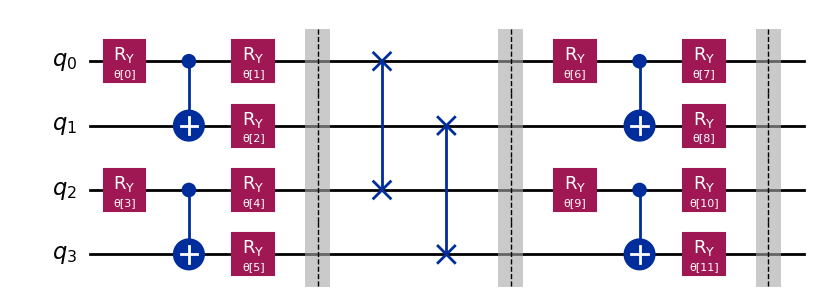

In [5]:
def apply_triangle_block(qc, q_control, q_target, params):
    """
    Constructs a foundational 2-qubit Triangle Block probability generator.
    Features 3 parameterized Ry gates and 1 entangling CNOT gate.
    """
    qc.ry(params[0], q_control)
    qc.cx(q_control, q_target)
    qc.ry(params[1], q_control)
    qc.ry(params[2], q_target)

def build_universal_ansatz(num_qubits, reps=1):
    """
    Generates a generalized hierarchically structured Universal Ansatz
    for a given number of qubits, based on the Triangle Block and SWAP layer pattern.
    This version includes a 'reps' parameter to control the depth of the ansatz.

    Args:
        num_qubits (int): The number of qubits for the ansatz. Must be an even number.
        reps (int): The number of times to repeat the block layers to increase depth.

    Returns:
        tuple: A tuple containing the QuantumCircuit and the ParameterVector.
    """
    if num_qubits % 2 != 0:
        raise ValueError("num_qubits must be an even number for this ansatz architecture.")

    qc = QuantumCircuit(num_qubits)

    # Correct calculation for total_params:
    # `reps` repetitions implies `reps + 1` Triangle Block layers.
    # Each Triangle Block layer has (num_qubits // 2) * 3 parameters.
    total_params = (reps + 1) * (num_qubits // 2) * 3
    theta = ParameterVector('θ', total_params)
    param_idx = 0

    # Initial Parallel Triangle Blocks
    for i in range(0, num_qubits, 2):
        apply_triangle_block(qc, i, i+1, theta[param_idx : param_idx + 3])
        param_idx += 3
    qc.barrier()

    # Subsequent repetitions of SWAP and Parallel Triangle Blocks
    for r in range(reps):
        # Dual SWAP gates to interconnect subsystems
        for i in range(num_qubits // 2):
            qc.swap(i, i + num_qubits // 2)
        qc.barrier()

        # Parallel Triangle Blocks
        for i in range(0, num_qubits, 2):
            apply_triangle_block(qc, i, i+1, theta[param_idx : param_idx + 3])
            param_idx += 3
        qc.barrier()

    return qc, theta

# Draw the circuit architecture to verify its layout for 8 qubits with depth 2
# (i.e., reps = 1 for the original structure, reps = 2 for deeper)
ansatz_circuit_deeper, parameters_deeper = build_universal_ansatz(num_qubits=4, reps=1)
fig_deeper = ansatz_circuit_deeper.draw('mpl')
display(fig_deeper)
plt.close(fig_deeper) # Close the figure to prevent it from being displayed twice or consuming memory


The `build_universal_ansatz` function has been updated to accept a `reps` parameter, controlling the number of repetitions of the SWAP and Triangle Block layers. For `reps=2`, we effectively have three layers of Triangle Blocks and two layers of SWAP gates, increasing the circuit's depth and parameter count. Now, let's re-run the 8-qubit VQE with this deeper ansatz.

In [6]:
def run_vqe_and_get_error_delta_deeper_ansatz(num_qubits, maxiter=60, reps=1):
    """
    Runs the VQE optimization for a given number of qubits and returns the absolute error delta,
    using a deeper ansatz controlled by 'reps'.
    """
    print(f"\n--- Running VQE for {num_qubits} qubits with maxiter={maxiter} and reps={reps} ---")

    # 1. Generate Hamiltonian
    h_op, h_mat = generate_black_scholes_hamiltonian(num_qubits=num_qubits)

    # 2. Build Deeper Ansatz
    ansatz_qc, params = build_universal_ansatz(num_qubits=num_qubits, reps=reps)

    # Clear energy_history for this specific run
    energy_history.clear()

    # 3. Initialize parameters for optimization
    initial_guess = np.random.uniform(0, 2 * np.pi, len(params))

    # 4. Run Optimization
    opt_result = minimize(
        vqe_objective_function,
        initial_guess,
        args=(ansatz_qc, h_op, estimator),
        method='COBYLA',
        options={'maxiter': maxiter}
    )

    # 5. Compute exact classical solution
    exact_ground_state = np.linalg.eigvalsh(h_mat)[0]

    # 6. Calculate error delta
    error_delta = abs(opt_result.fun - exact_ground_state)

    print(f"VQE Computed Ground State Energy ({num_qubits} qubits, reps={reps}): {opt_result.fun:.4f}")
    print(f"Exact Classical Diagonalized Energy ({num_qubits} qubits): {exact_ground_state:.4f}")
    print(f"Absolute Calculation Error Delta ({num_qubits} qubits, reps={reps}): {error_delta:.4f}")

    return error_delta

# Ensure energy_history, estimator, and vqe_objective_function are defined.
# They are expected to be initialized in cell tC80u-WirFoi.
# If that cell hasn't been run, this will prevent a NameError.
# (Assuming `estimator` and `vqe_objective_function` are indeed available here
#  as only `energy_history` caused a NameError in the traceback).

# If `energy_history` is not defined globally, initialize it here.
# This might be redundant if tC80u-WirFoi was run, but ensures the variable exists.
if 'energy_history' not in globals():
    energy_history = []

# Initialize comparison_error_deltas if not already defined (to prevent NameError if previous cell wasn't run)
if 'comparison_error_deltas' not in globals():
    comparison_error_deltas = {}

# Run VQE for 8 qubits with a deeper ansatz (reps=2) and increased maxiter
# Update the comparison_error_deltas dictionary
comparison_error_deltas[4] = run_vqe_and_get_error_delta_deeper_ansatz(4, maxiter=200, reps=1)
# run_vqe_and_get_error_delta_deeper_ansatz(4, maxiter=200, reps=1)

print("\n--- Updated Comparison Results ---")
for n_q, error in comparison_error_deltas.items():
    print(f"Number of Qubits: {n_q}, Error Delta: {error:.4f}")


--- Running VQE for 4 qubits with maxiter=200 and reps=1 ---
VQE Computed Ground State Energy (4 qubits, reps=1): 0.0023
Exact Classical Diagonalized Energy (4 qubits): 0.0013
Absolute Calculation Error Delta (4 qubits, reps=1): 0.0010

--- Updated Comparison Results ---
Number of Qubits: 4, Error Delta: 0.0010


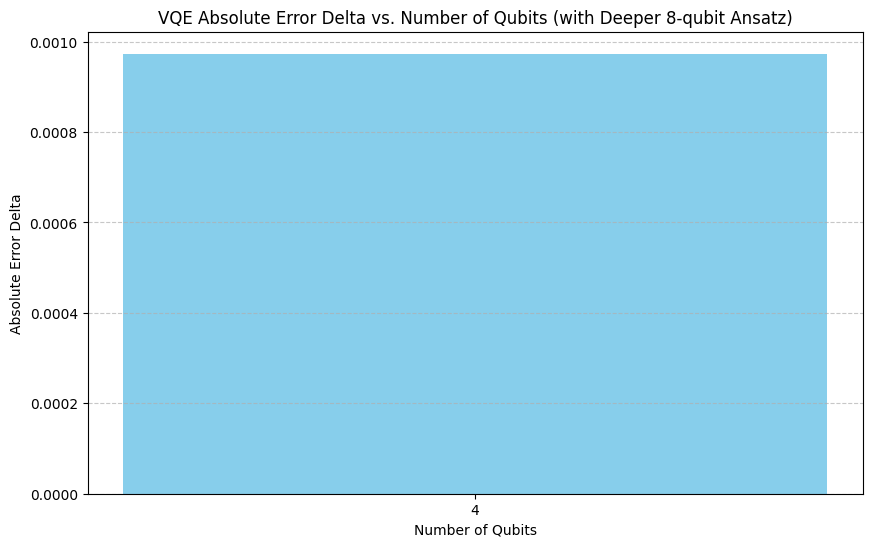

In [7]:
# Re-plot the comparison results including the new deeper ansatz result for 8 qubits
num_qubits_labels = list(comparison_error_deltas.keys())
error_deltas = list(comparison_error_deltas.values())

fig = plt.figure(figsize=(10, 6))
# Add a specific color for the deeper 8-qubit case, e.g., 'darkgreen'
colors = ['skyblue', 'lightcoral', 'darkgreen'] # Assuming 4, 6, 8 qubits in order
plt.bar(num_qubits_labels, error_deltas, color=colors)
plt.xlabel("Number of Qubits")
plt.ylabel("Absolute Error Delta")
plt.title("VQE Absolute Error Delta vs. Number of Qubits (with Deeper 8-qubit Ansatz)")
plt.xticks(num_qubits_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [9]:
# Initialize runtime primitives and tracking arrays
estimator = Estimator()
energy_history = []

def vqe_objective_function(param_values, ansatz, hamiltonian, primitive_estimator):
    """
    Computes the expectation energy value C(θ) via quantum measurement
    to pass as the objective function back into the classical optimizer.
    """
    # Run the modern parameter binding sequence through the Estimator
    job = primitive_estimator.run([ansatz], [hamiltonian], [param_values])
    result = job.result()
    energy = result.values[0]

    # Record history for plotting
    energy_history.append(energy)
    return energy

print("VQE execution engine configured.")

VQE execution engine configured.


Starting TQC-VQE Optimization Loop...

--- OPTIMIZATION MATRIX RESULTS ---
VQE Computed Ground State Energy: 0.002992517089843747
Exact Classical Diagonalized Energy: 0.0013263900228458914
Absolute Calculation Error Delta: 0.0016661270669978557


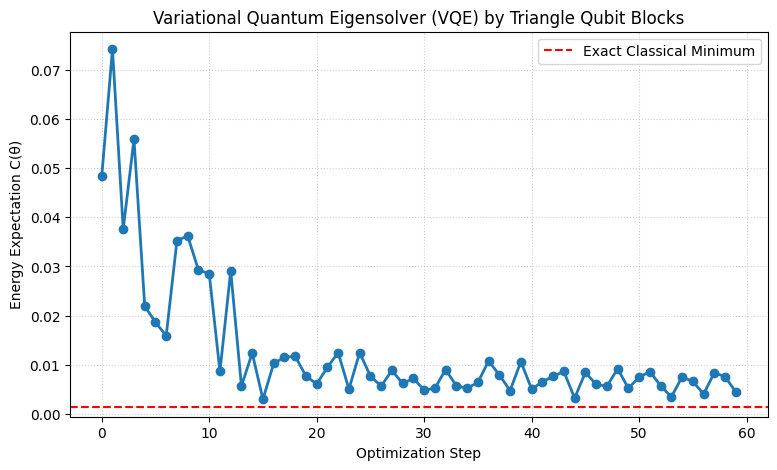

In [10]:
# Clear any residual run logs
energy_history.clear()

# Define ansatz_circuit and parameters for this VQE run
# Assuming a 4-qubit system and default reps=1 for this standalone run.
num_qubits_for_this_run = 4
ansatz_circuit, parameters = build_universal_ansatz(num_qubits=num_qubits_for_this_run, reps=1)

# Initialize parameter array to random starting vectors
initial_guess = np.random.uniform(0, 2 * np.pi, len(parameters))

print("Starting TQC-VQE Optimization Loop...")
# Optimize using SciPy optimization modules
opt_result = minimize(
    vqe_objective_function,
    initial_guess,
    args=(ansatz_circuit, H_operator, estimator),
    method='COBYLA',
    options={'maxiter': 60}
)

# Compute exact classical solution for precision benchmarking
exact_ground_state = np.linalg.eigvalsh(H_matrix)[0]

print("\n--- OPTIMIZATION MATRIX RESULTS ---")
print(f"VQE Computed Ground State Energy: {opt_result.fun}")
print(f"Exact Classical Diagonalized Energy: {exact_ground_state}")
print(f"Absolute Calculation Error Delta: {abs(opt_result.fun - exact_ground_state)}")

# Generate the performance tracking visualization from Figure 3 of the paper
plt.figure(figsize=(9, 5))
plt.plot(energy_history, marker='o', color='#1f77b4', linestyle='-', linewidth=2)
plt.axhline(y=exact_ground_state, color='r', linestyle='--', label='Exact Classical Minimum')
plt.title("Variational Quantum Eigensolver (VQE) by Triangle Qubit Blocks", fontsize=12)
plt.xlabel("Optimization Step", fontsize=10)
plt.ylabel("Energy Expectation C(θ)", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### Comparing VQE Error Delta Across Different Qubit Counts

To analyze the performance of the VQE for varying numbers of qubits, we will re-run the optimization for 4, 6, and 8 qubits. For each run, we will record the absolute error delta between the VQE computed ground state energy and the exact classical ground state energy. Finally, we will visualize these error deltas.

In [11]:
def run_vqe_and_get_error_delta(num_qubits, maxiter=60):
    """
    Runs the VQE optimization for a given number of qubits and returns the absolute error delta.
    """
    print(f"\n--- Running VQE for {num_qubits} qubits with maxiter={maxiter} ---")

    # 1. Generate Hamiltonian
    h_op, h_mat = generate_black_scholes_hamiltonian(num_qubits=num_qubits)

    # 2. Build Ansatz
    ansatz_qc, params = build_universal_ansatz(num_qubits=num_qubits)

    # Clear energy_history for this specific run (if you want to plot its progress)
    # For this comparison, we just need the final error, so clearing is fine.
    energy_history.clear()

    # 3. Initialize parameters for optimization
    initial_guess = np.random.uniform(0, 2 * np.pi, len(params))

    # 4. Run Optimization
    opt_result = minimize(
        vqe_objective_function,
        initial_guess,
        args=(ansatz_qc, h_op, estimator),
        method='COBYLA',
        options={'maxiter': maxiter}
    )

    # 5. Compute exact classical solution
    exact_ground_state = np.linalg.eigvalsh(h_mat)[0]

    # 6. Calculate error delta
    error_delta = abs(opt_result.fun - exact_ground_state)

    print(f"VQE Computed Ground State Energy ({num_qubits} qubits): {opt_result.fun:.4f}")
    print(f"Exact Classical Diagonalized Energy ({num_qubits} qubits): {exact_ground_state:.4f}")
    print(f"Absolute Calculation Error Delta ({num_qubits} qubits): {error_delta:.4f}")

    return error_delta

# Dictionary to store results
comparison_error_deltas = {}

# Run VQE for 4 and 6 qubits with default maxiter, and for 8 qubits with increased maxiter
comparison_error_deltas[4] = run_vqe_and_get_error_delta(4)
comparison_error_deltas[6] = run_vqe_and_get_error_delta(6)
comparison_error_deltas[8] = run_vqe_and_get_error_delta(8, maxiter=200)

print("\n--- Comparison Results --- ")
for n_q, error in comparison_error_deltas.items():
    print(f"Number of Qubits: {n_q}, Error Delta: {error:.4f}")


--- Running VQE for 4 qubits with maxiter=60 ---
VQE Computed Ground State Energy (4 qubits): 0.0013
Exact Classical Diagonalized Energy (4 qubits): 0.0013
Absolute Calculation Error Delta (4 qubits): 0.0000

--- Running VQE for 6 qubits with maxiter=60 ---
VQE Computed Ground State Energy (6 qubits): 0.3922
Exact Classical Diagonalized Energy (6 qubits): 0.0013
Absolute Calculation Error Delta (6 qubits): 0.3909

--- Running VQE for 8 qubits with maxiter=200 ---
VQE Computed Ground State Energy (8 qubits): 0.1468
Exact Classical Diagonalized Energy (8 qubits): 0.0013
Absolute Calculation Error Delta (8 qubits): 0.1456

--- Comparison Results --- 
Number of Qubits: 4, Error Delta: 0.0000
Number of Qubits: 6, Error Delta: 0.3909
Number of Qubits: 8, Error Delta: 0.1456


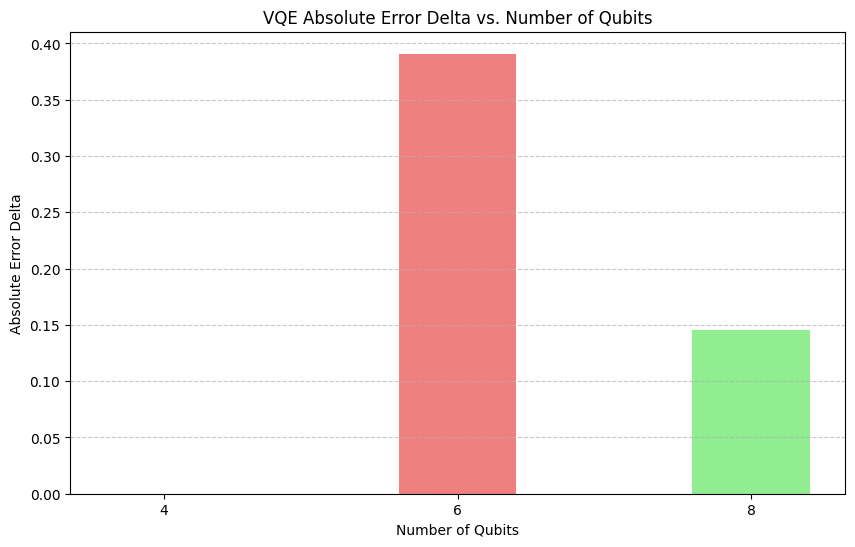

In [12]:
num_qubits_labels = list(comparison_error_deltas.keys())
error_deltas = list(comparison_error_deltas.values())

fig = plt.figure(figsize=(10, 6))
plt.bar(num_qubits_labels, error_deltas, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel("Number of Qubits")
plt.ylabel("Absolute Error Delta")
plt.title("VQE Absolute Error Delta vs. Number of Qubits")
plt.xticks(num_qubits_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()